In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("AmesHousing[1].csv")

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# House Price Prediction using Linear Regression

## Objective
Predict residential house prices using Linear Regression and evaluate the model performance.

In [4]:
print("Shape:", df.shape)

df = df[["Overall Qual", "Gr Liv Area", "Garage Cars", "SalePrice"]]

df.info()

Shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Overall Qual  2930 non-null   int64  
 1   Gr Liv Area   2930 non-null   int64  
 2   Garage Cars   2929 non-null   float64
 3   SalePrice     2930 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 91.7 KB


## Dataset Inspection

The dataset contains important housing features and the target variable **SalePrice**.

In [5]:
print(df.isnull().sum())

Overall Qual    0
Gr Liv Area     0
Garage Cars     1
SalePrice       0
dtype: int64


## Data Preprocessing

Selected the most relevant numerical features and verified that there are no missing values.

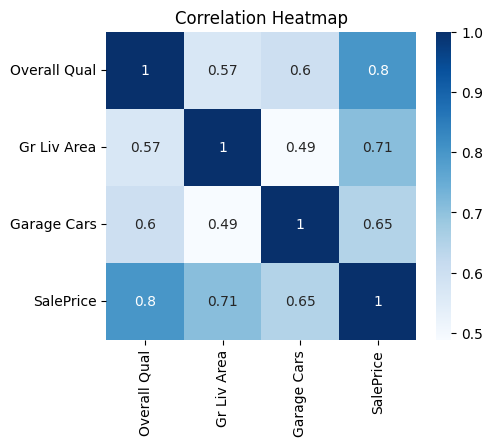

In [6]:
plt.figure(figsize=(5,4))

sns.heatmap(df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

The heatmap shows how each feature is related to house prices.

In [8]:
df['Garage Cars'] = df['Garage Cars'].fillna(df['Garage Cars'].mean())
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

/tmp/ipykernel_3115/1737239103.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Garage Cars'].fillna(df['Garage Cars'].mean(), inplace=True)


## Model Training

The dataset is divided into training and testing sets before applying Linear Regression.

In [10]:
score = r2_score(y_test, pred)

print("R² Score:", round(score, 3))

R² Score: 0.76


## Model Evaluation

R² Score measures how accurately the model predicts house prices.

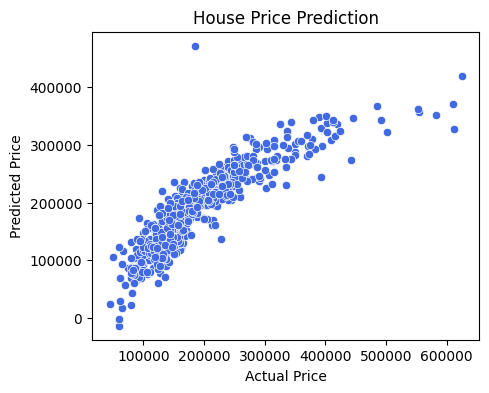

In [11]:
plt.figure(figsize=(5,4))

sns.scatterplot(x=y_test, y=pred, color="royalblue")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Price Prediction")

plt.show()

# Conclusion

- Successfully built a House Price Prediction model.
- Linear Regression predicts house prices using key housing features.
- The model was evaluated using the R² Score.
- This project demonstrates data preprocessing, visualization, model training, and prediction.